In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import re
from PIL.ImageColor import colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from pathlib import Path

In [6]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root folder named '{project_folder_name}'.")
print("Project root path:")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.dynamic import PEMFC_dyn
from model.static import PEMFC_stat
from model.coefficients import *
from configuration.initialize import *

Project root path:


In [7]:
I_points = [10, 20, 30, 40, 50]

dyn_sim_log = {}
stat_sim_log = {}


for P_des in [1.3,1.4,1.5]:
    for T_des in [323.15,333.15,343.15]:
        states_dyn = []
        states_stat = []
        print(f"Simulating for RHC={0.5}, P_des={P_des} bar, T_des={T_des} K...")
        for I_LOAD in I_points:
            # --------------- Steady-state Simulation  --------------- #
            operating_inputs_stat = operating_inputs.copy()
            operating_inputs_stat = {'Tfc': T_des, 'Phi_a_des': 0.7, 'Phi_c_des': 0.5,
                                                    'Pa_des': P_des * 1e5, 'Pc_des': P_des * 1e5,
                                                    'Win_c': 4.8, 'Wout_c': Wout_c_points[I_points.index(I_LOAD)], 'Win_a': 4.8, 'Wout_a': 4.8}
            model = PEMFC_stat(parameters,operating_inputs_stat)
            sol = model.solve(I_LOAD/parameters['Aact'])
            # --------------- Log states for steady-state simulation  --------------- #
            states_stat.append(sol)
        
        # --------------- Log states for both simulations  --------------- #
        stat_sim_log["RHA"+str(0)+"/RHC" + str(0.5) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_stat}

Simulating for RHC=0.5, P_des=1.3 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.3 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.3 bar, T_des=343.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.4 bar, T_des=343.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=323.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=333.15 K...
Simulating for RHC=0.5, P_des=1.5 bar, T_des=343.15 K...


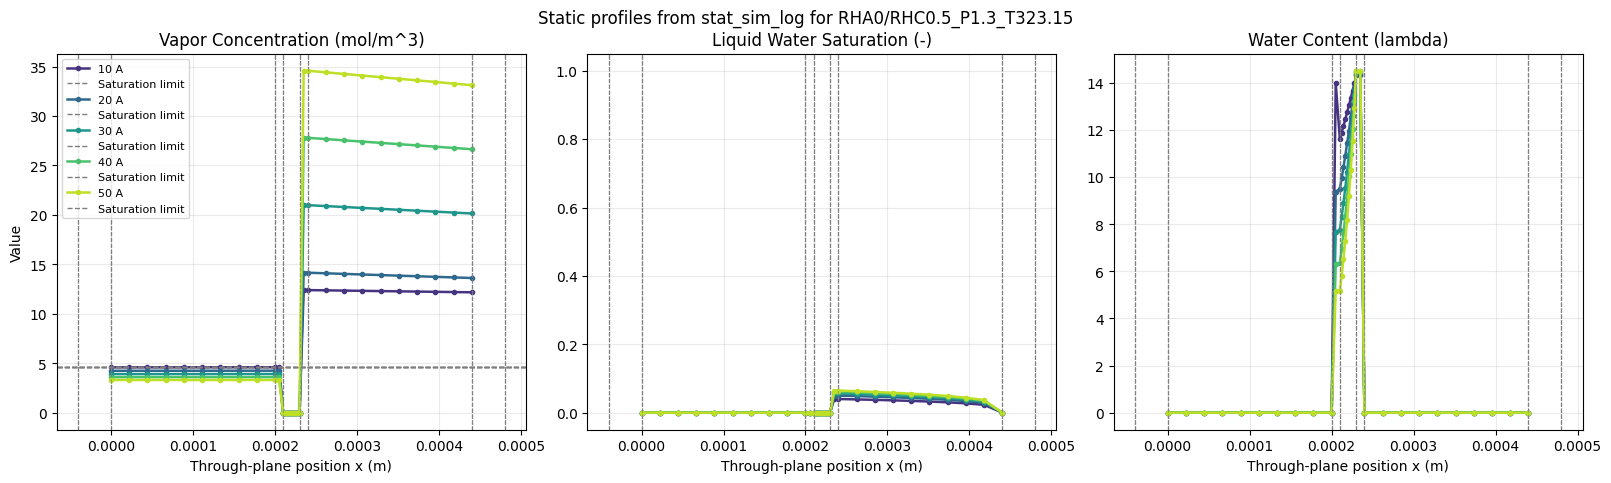

In [8]:
case_keys = list(stat_sim_log)
selected_case = case_keys[0]

states = stat_sim_log[selected_case]["states"]
temperature_match = re.search(r"_T([0-9.]+)$", selected_case)
if temperature_match is None:
    raise ValueError(f"Could not extract the temperature from '{selected_case}'.")

case_temperature = float(temperature_match.group(1))
plot_nodes = nodes[1:-1]
profile_panels = [
    ("v", "Vapor Concentration (mol/m^3)"),
    ("saturation", "Liquid Water Saturation (-)"),
    ("lambda", "Water Content (lambda)"),
]


def build_static_profiles(state):
    saturation_acl = float(state["s_agdl"][-1])
    saturation_ccl = float(state["s_cgdl"][0])
    return {
        "v": list(np.asarray(state["Cv_agdl"])) + [float(state["Cv_acl"]), float(state["Cv_ccl"])] + list(np.asarray(state["Cv_cgdl"])),
        "saturation": list(np.asarray(state["s_agdl"])) + [saturation_acl, saturation_ccl] + list(np.asarray(state["s_cgdl"])),
        "lambda": [float(state["lambda_acl"])] + list(np.asarray(state["lambda_mem"])) + [float(state["lambda_ccl"])],
    }


fig, axes = plt.subplots(1, len(profile_panels), figsize=(16, 4.5), constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(states)))

for current, state, color in zip(I_points, states, colors):
    profiles = build_static_profiles(state)
    for ax, (profile_key, title) in zip(axes, profile_panels):
        y_values = expand_profile_on_nodes(profile_key, profiles[profile_key])
        ax.plot(plot_nodes, y_values, marker="o", markersize=3, linewidth=1.8, color=color, label=f"{current} A")
        if profile_key == "v":
            ax.axhline(C_v_sat(case_temperature), color="tab:gray", linestyle="--", linewidth=1.0, label="Saturation limit")
        if profile_key == "saturation":
            ax.set_ylim(-0.05, 1.05)
        for x_border in borders:
            ax.axvline(x=x_border, color="tab:gray", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.set_title(title)
        ax.set_xlabel("Through-plane position x (m)")
        ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Value")
axes[0].legend(loc="best", fontsize=8)
fig.suptitle(f"Static profiles from stat_sim_log for {selected_case}", y=1.04)
plt.show()

In [14]:
hfr_data_path = project_root / "data" / "HFR.xlsx"
expdata_hfr = pd.read_excel(hfr_data_path, sheet_name=None)

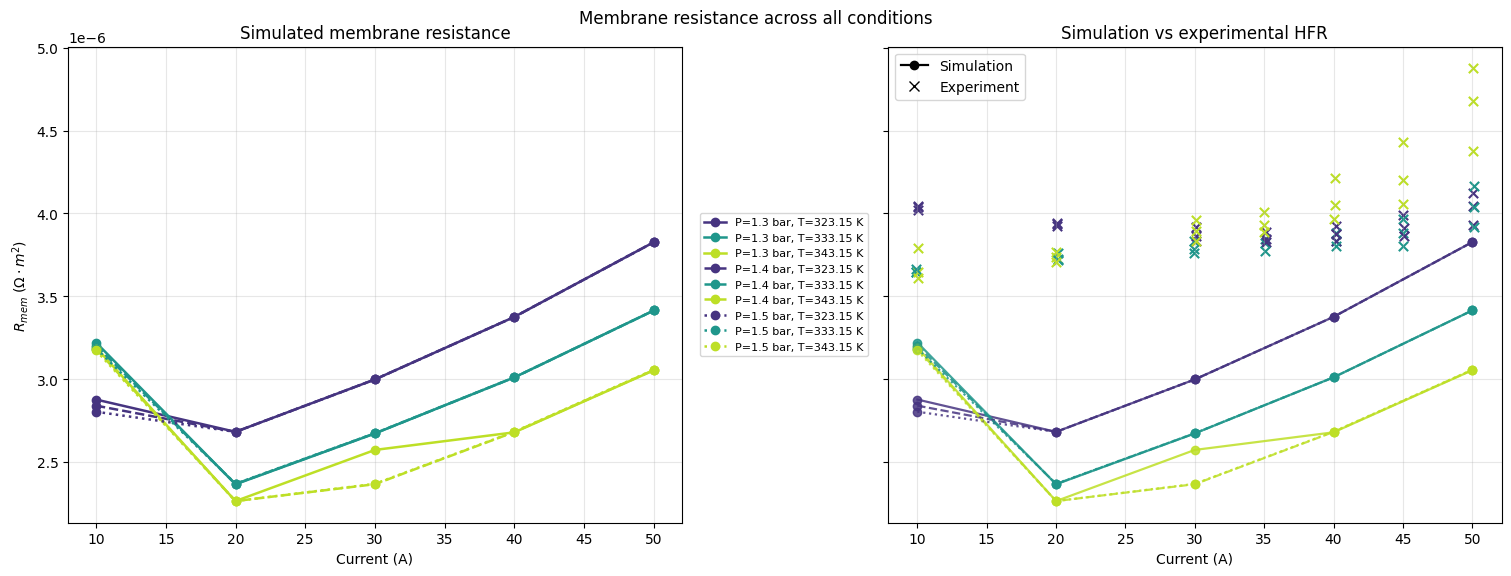

In [15]:
from ast import literal_eval

case_keys = list(stat_sim_log)


def case_to_sheet_name(pressure_bar, temperature_k, humidity=50):
    temperature_c = int(round(temperature_k - 273.15))
    pressure_code = int(round((pressure_bar - 1.0) * 1000))
    return f"T{temperature_c}_P{pressure_code}_HRC{humidity}"


def parse_experimental_hfr(sheet_data):
    resistance_values = []
    for raw_value in sheet_data["R"]:
        parsed_value = raw_value
        if isinstance(raw_value, str):
            parsed_value = literal_eval(raw_value)
        resistance_values.append(float(parsed_value[0]) * 1e-7)
    return pd.DataFrame(
        {
            "current_a": pd.to_numeric(sheet_data["I_LOAD"], errors="coerce"),
            "rmem_ohm_m2": resistance_values,
        }
    ).dropna()


case_metadata = []
for case_key in case_keys:
    pressure_match = re.search(r"_P([0-9.]+)_T", case_key)
    temperature_match = re.search(r"_T([0-9.]+)$", case_key)
    if pressure_match is None or temperature_match is None:
        raise ValueError(f"Could not extract pressure/temperature from '{case_key}'.")

    pressure_bar = float(pressure_match.group(1))
    temperature_k = float(temperature_match.group(1))
    case_metadata.append(
        {
            "case_key": case_key,
            "pressure_bar": pressure_bar,
            "temperature_k": temperature_k,
            "sheet_name": case_to_sheet_name(pressure_bar, temperature_k),
        }
    )

unique_pressures = sorted({item["pressure_bar"] for item in case_metadata})
unique_temperatures = sorted({item["temperature_k"] for item in case_metadata})
line_styles = ["-", "--", ":", "-."]
pressure_styles = {
    pressure: line_styles[index % len(line_styles)] for index, pressure in enumerate(unique_pressures)
}
temp_colors = {
    temperature: color
    for temperature, color in zip(unique_temperatures, plt.cm.viridis(np.linspace(0.15, 0.9, len(unique_temperatures))))
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True, sharey=True)
ax_model, ax_compare = axes

for item in sorted(case_metadata, key=lambda entry: (entry["pressure_bar"], entry["temperature_k"])):
    states = stat_sim_log[item["case_key"]]["states"]
    rmem_values = [float(state["Rohm"] - parameters["Re"]) for state in states]
    curve_label = f"P={item['pressure_bar']:.1f} bar, T={item['temperature_k']:.2f} K"

    ax_model.plot(
        I_points,
        rmem_values,
        marker="o",
        linewidth=1.8,
        color=temp_colors[item["temperature_k"]],
        linestyle=pressure_styles[item["pressure_bar"]],
        label=curve_label,
    )

    ax_compare.plot(
        I_points,
        rmem_values,
        marker="o",
        linewidth=1.6,
        color=temp_colors[item["temperature_k"]],
        linestyle=pressure_styles[item["pressure_bar"]],
        alpha=0.85,
    )

    if item["sheet_name"] in expdata_hfr:
        experimental_hfr = parse_experimental_hfr(expdata_hfr[item["sheet_name"]])
        ax_compare.scatter(
            experimental_hfr["current_a"],
            experimental_hfr["rmem_ohm_m2"],
            color=temp_colors[item["temperature_k"]],
            marker="x",
            s=45,
        )

ax_model.set_title("Simulated membrane resistance")
ax_compare.set_title("Simulation vs experimental HFR")

for axis in axes:
    axis.set_xlabel("Current (A)")
    axis.grid(True, alpha=0.3)

ax_model.set_ylabel(r"$R_{mem}$ ($\Omega\cdot m^2$)")
ax_model.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)

comparison_handles = [
    plt.Line2D([0], [0], color="black", linewidth=1.6, marker="o", label="Simulation"),
    plt.Line2D([0], [0], color="black", linestyle="None", marker="x", markersize=7, label="Experiment"),
]
ax_compare.legend(handles=comparison_handles, loc="best")

fig.suptitle("Membrane resistance across all conditions", y=1.02)
plt.show()

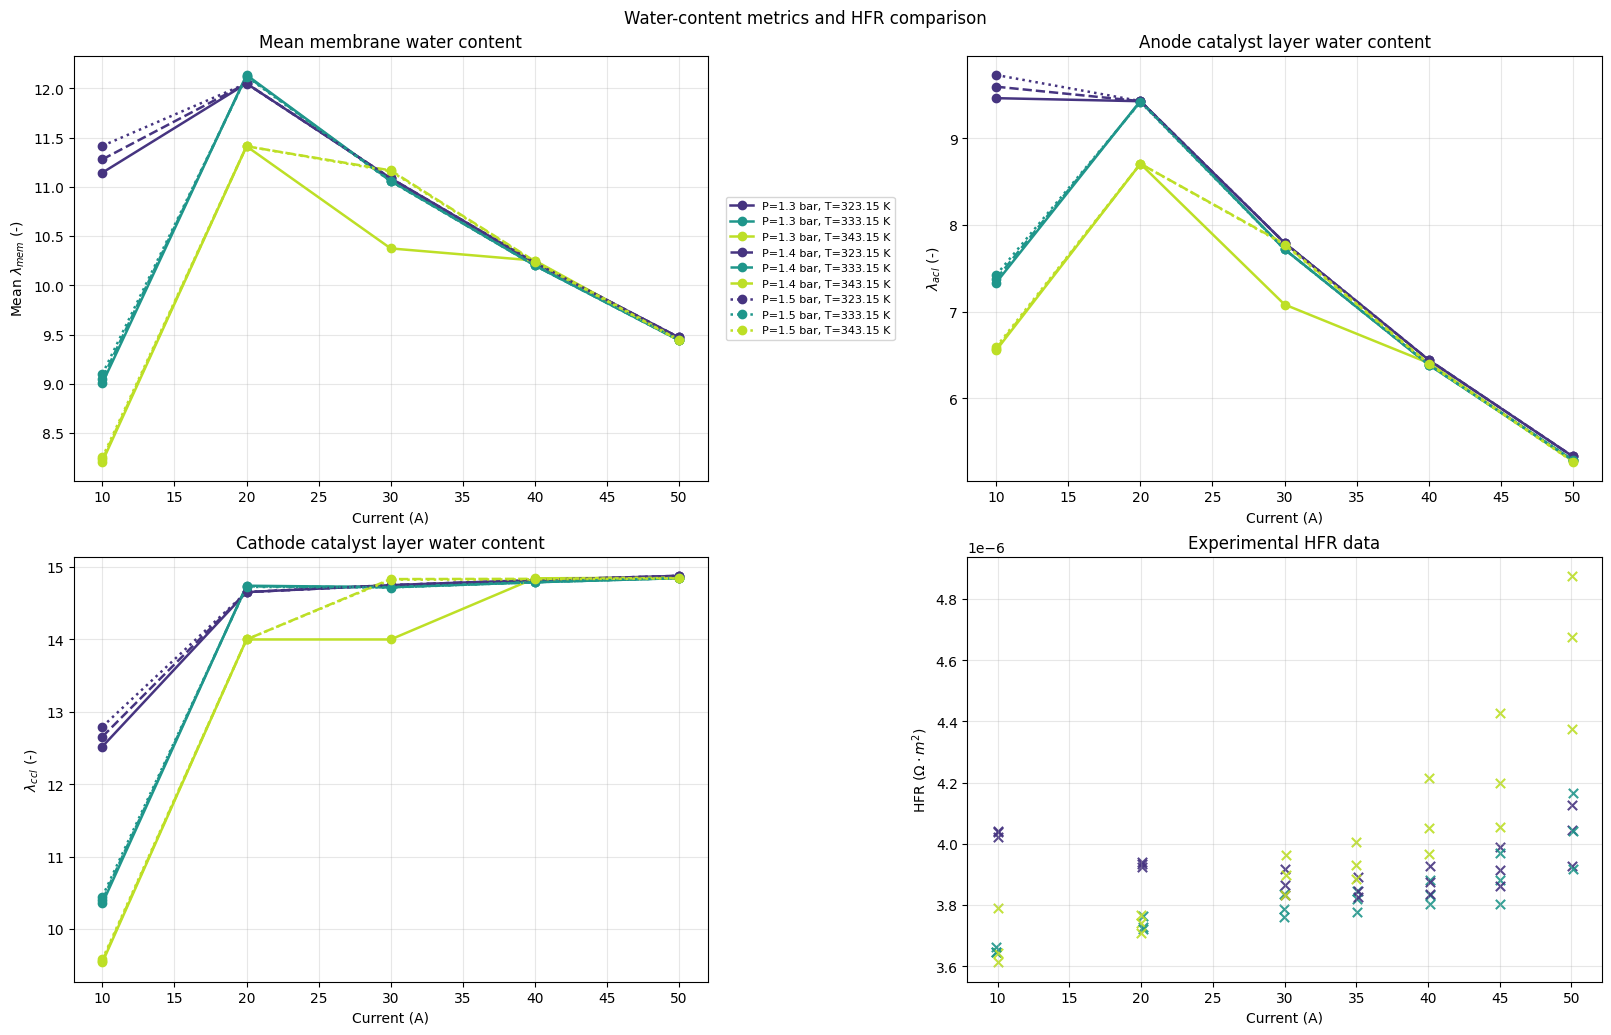

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True, sharex=False)
ax_lambda_mem, ax_lambda_acl, ax_lambda_ccl, ax_hfr = axes.flatten()

for item in sorted(case_metadata, key=lambda entry: (entry["pressure_bar"], entry["temperature_k"])):
    states = stat_sim_log[item["case_key"]]["states"]
    mean_lambda_mem = np.array([float(np.mean(state["lambda_mem"])) for state in states])
    lambda_acl = np.array([float(state["lambda_acl"]) for state in states])
    lambda_ccl = np.array([float(state["lambda_ccl"]) for state in states])
    curve_label = f"P={item['pressure_bar']:.1f} bar, T={item['temperature_k']:.2f} K"
    color = temp_colors[item["temperature_k"]]
    linestyle = pressure_styles[item["pressure_bar"]]

    ax_lambda_mem.plot(
        I_points,
        mean_lambda_mem,
        marker="o",
        linewidth=1.8,
        color=color,
        linestyle=linestyle,
        label=curve_label,
    )
    ax_lambda_acl.plot(
        I_points,
        lambda_acl,
        marker="o",
        linewidth=1.8,
        color=color,
        linestyle=linestyle,
    )
    ax_lambda_ccl.plot(
        I_points,
        lambda_ccl,
        marker="o",
        linewidth=1.8,
        color=color,
        linestyle=linestyle,
    )

    if item["sheet_name"] in expdata_hfr:
        experimental_hfr = parse_experimental_hfr(expdata_hfr[item["sheet_name"]])
        ax_hfr.scatter(
            experimental_hfr["current_a"],
            experimental_hfr["rmem_ohm_m2"],
            color=color,
            marker="x",
            s=45,
            alpha=0.9,
            label=curve_label,
        )

for axis in [ax_lambda_mem, ax_lambda_acl, ax_lambda_ccl, ax_hfr]:
    axis.grid(True, alpha=0.3)

ax_lambda_mem.set_title("Mean membrane water content")
ax_lambda_mem.set_xlabel("Current (A)")
ax_lambda_mem.set_ylabel(r"Mean $\lambda_{mem}$ (-)")
ax_lambda_mem.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)

ax_lambda_acl.set_title("Anode catalyst layer water content")
ax_lambda_acl.set_xlabel("Current (A)")
ax_lambda_acl.set_ylabel(r"$\lambda_{acl}$ (-)")

ax_lambda_ccl.set_title("Cathode catalyst layer water content")
ax_lambda_ccl.set_xlabel("Current (A)")
ax_lambda_ccl.set_ylabel(r"$\lambda_{ccl}$ (-)")

ax_hfr.set_title("Experimental HFR data")
ax_hfr.set_xlabel("Current (A)")
ax_hfr.set_ylabel(r"HFR ($\Omega\cdot m^2$)")

fig.suptitle("Water-content metrics and HFR comparison", y=1.02)
plt.show()

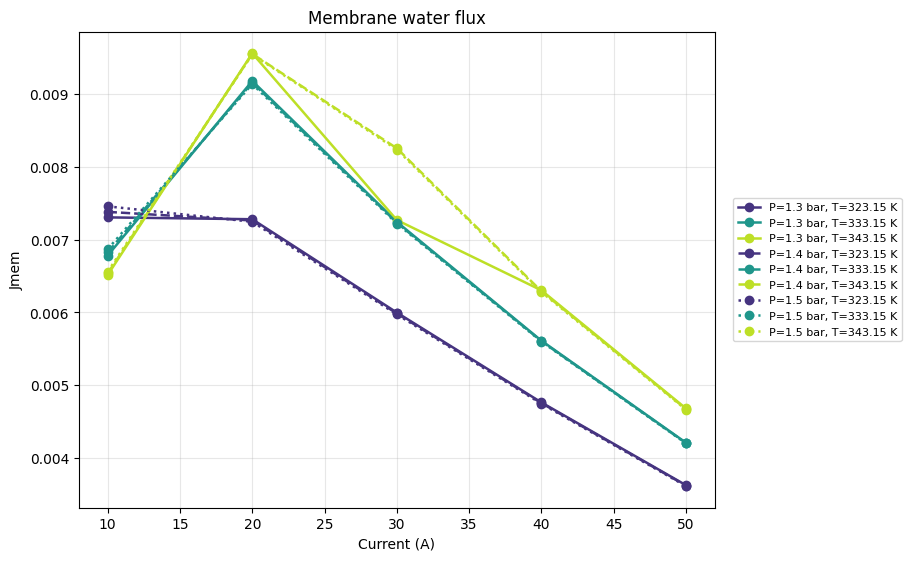

In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)

for item in sorted(case_metadata, key=lambda entry: (entry["pressure_bar"], entry["temperature_k"])):
    states = stat_sim_log[item["case_key"]]["states"]
    jmem_values = np.array([float(state["Jnet"]) for state in states])
    curve_label = f"P={item['pressure_bar']:.1f} bar, T={item['temperature_k']:.2f} K"

    ax.plot(
        I_points,
        jmem_values,
        marker="o",
        linewidth=1.8,
        color=temp_colors[item["temperature_k"]],
        linestyle=pressure_styles[item["pressure_bar"]],
        label=curve_label,
    )

ax.set_title("Membrane water flux")
ax.set_xlabel("Current (A)")
ax.set_ylabel("Jmem")
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.show()

In [ ]:
from IPython.display import HTML, display
from scipy.optimize import differential_evolution

initial_wout_c_points = np.array(Wout_c_points, dtype=float)
fit_cases = [item for item in case_metadata if item["sheet_name"] in expdata_hfr]
maxiter = 12
popsize = 6
parameter_count = len(I_points)
solves_per_curve = len(fit_cases) * len(I_points)
fixed_curve_passes = 4
max_optimizer_evaluations = (maxiter + 1) * popsize * parameter_count
progress_state = {
    "completed": 0,
    "total": max(solves_per_curve * (fixed_curve_passes + max_optimizer_evaluations), 1),
    "phase": "Preparing calibration",
    "last_rendered": -1,
    "optimizer_evaluations": 0,
    "best_score": None,
}
progress_display = display(HTML(""), display_id=True)


def render_progress(force=False):
    completed = progress_state["completed"]
    total = max(progress_state["total"], 1)

    if not force and completed - progress_state["last_rendered"] < len(I_points):
        return

    percent = min(100.0 * completed / total, 99.9 if progress_state["phase"] != "Calibration completed" else 100.0)
    best_score_text = "-"
    if progress_state["best_score"] is not None:
        best_score_text = f"{progress_state['best_score']:.4f} micro-ohm m^2"

    html = f"""
    <div style='width: 100%; max-width: 720px;'>
        <div style='font-weight: 600; margin-bottom: 4px;'>{progress_state['phase']}</div>
        <progress value='{completed}' max='{total}' style='width: 100%; height: 18px;'></progress>
        <div style='font-size: 12px; margin-top: 4px;'>{completed} / {total} solves completed ({percent:.1f}%)</div>
        <div style='font-size: 12px; margin-top: 2px;'>Objective evaluations: {progress_state['optimizer_evaluations']} / {max_optimizer_evaluations}</div>
        <div style='font-size: 12px; margin-top: 2px;'>Best RMSE so far: {best_score_text}</div>
    </div>
    """
    progress_display.update(HTML(html))
    progress_state["last_rendered"] = completed


def advance_progress(increment=0, phase=None, force=False):
    if phase is not None:
        progress_state["phase"] = phase
    progress_state["completed"] += increment
    render_progress(force=force)


def simulate_rmem_curves(wout_values, phase_label):
    simulated_curves = {}
    for case_index, item in enumerate(fit_cases, start=1):
        rmem_curve = []
        for current_index, (current_value, wout_c) in enumerate(zip(I_points, wout_values), start=1):
            advance_progress(
                phase=f"{phase_label}: case {case_index}/{len(fit_cases)}, current {current_index}/{len(I_points)}"
            )
            operating_inputs_stat = {
                "Tfc": item["temperature_k"],
                "Phi_a_des": 0,
                "Phi_c_des": 0.5,
                "Pa_des": item["pressure_bar"] * 1e5,
                "Pc_des": item["pressure_bar"] * 1e5,
                "Win_c": 4.8,
                "Wout_c": float(wout_c),
                "Win_a": 4.8,
                "Wout_a": 4.8,
            }
            model = PEMFC_stat(parameters, operating_inputs_stat)
            solution = model.solve(current_value / parameters["Aact"])
            rmem_curve.append(float(solution["Rohm"] - parameters["Re"]))
            advance_progress(increment=1)
        simulated_curves[item["case_key"]] = np.array(rmem_curve)
    return simulated_curves


def build_residual_vector(wout_values, phase_label):
    simulated_curves = simulate_rmem_curves(wout_values, phase_label)
    residuals = []
    for item in fit_cases:
        experimental_hfr = parse_experimental_hfr(expdata_hfr[item["sheet_name"]])
        simulated_at_experimental_currents = np.interp(
            experimental_hfr["current_a"].to_numpy(),
            np.asarray(I_points, dtype=float),
            simulated_curves[item["case_key"]],
        )
        residuals.extend((simulated_at_experimental_currents - experimental_hfr["rmem_ohm_m2"].to_numpy()) / 1e-6)
    return np.asarray(residuals)


def objective_function(wout_values):
    progress_state["optimizer_evaluations"] += 1
    residuals = build_residual_vector(
        wout_values,
        phase_label=f"Differential evolution: evaluation {progress_state['optimizer_evaluations']}/{max_optimizer_evaluations}",
    )
    rmse = float(np.sqrt(np.mean(residuals**2)))
    if progress_state["best_score"] is None or rmse < progress_state["best_score"]:
        progress_state["best_score"] = rmse
    render_progress(force=True)
    return rmse


def optimizer_callback(xk, convergence=0):
    best_rmse = progress_state["best_score"] if progress_state["best_score"] is not None else float("inf")
    advance_progress(
        phase=f"Differential evolution: completed generation, best RMSE {best_rmse:.4f} micro-ohm m^2, convergence {convergence:.4f}",
        force=True,
    )
    return False


advance_progress(phase="Evaluating initial mismatch", force=True)
initial_residuals = build_residual_vector(initial_wout_c_points, phase_label="Evaluating initial mismatch")
initial_rmse = float(np.sqrt(np.mean(initial_residuals**2)))
progress_state["best_score"] = initial_rmse
render_progress(force=True)

advance_progress(phase="Running differential evolution", force=True)
fit_result = differential_evolution(
    objective_function,
    bounds=[(1.0, 30.0)] * parameter_count,
    maxiter=maxiter,
    popsize=popsize,
    polish=False,
    seed=42,
    callback=optimizer_callback,
    updating="deferred",
)

fitted_wout_c_points = fit_result.x
advance_progress(phase="Evaluating fitted mismatch", force=True)
fitted_residuals = build_residual_vector(fitted_wout_c_points, phase_label="Evaluating fitted mismatch")
fitted_rmse = float(np.sqrt(np.mean(fitted_residuals**2)))
Wout_c_points = fitted_wout_c_points.tolist()

print("Optimization algorithm: differential evolution")
print("Optimization status:", fit_result.message)
print("Initial Wout_c_points:", np.round(initial_wout_c_points, 3).tolist())
print("Fitted  Wout_c_points:", np.round(fitted_wout_c_points, 3).tolist())
print(f"Initial RMSE: {initial_rmse:.4f} micro-ohm m^2")
print(f"Fitted  RMSE: {fitted_rmse:.4f} micro-ohm m^2")

advance_progress(phase="Generating initial comparison curves", force=True)
initial_curves = simulate_rmem_curves(initial_wout_c_points, phase_label="Generating initial comparison curves")
advance_progress(phase="Generating fitted comparison curves", force=True)
fitted_curves = simulate_rmem_curves(fitted_wout_c_points, phase_label="Generating fitted comparison curves")
advance_progress(phase="Finalizing plots", force=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
ax_wout, ax_fit = axes

ax_wout.plot(I_points, initial_wout_c_points, marker="o", linewidth=1.8, label="Initial")
ax_wout.plot(I_points, fitted_wout_c_points, marker="s", linewidth=1.8, label="Fitted")
ax_wout.set_title("Cathode outlet flow calibration")
ax_wout.set_xlabel("Current (A)")
ax_wout.set_ylabel("Wout_c")
ax_wout.grid(True, alpha=0.3)
ax_wout.legend(loc="best")

for item in sorted(fit_cases, key=lambda entry: (entry["pressure_bar"], entry["temperature_k"])):
    curve_label = f"P={item['pressure_bar']:.1f} bar, T={item['temperature_k']:.2f} K"
    color = temp_colors[item["temperature_k"]]
    linestyle = pressure_styles[item["pressure_bar"]]
    experimental_hfr = parse_experimental_hfr(expdata_hfr[item["sheet_name"]])

    ax_fit.plot(
        I_points,
        fitted_curves[item["case_key"]],
        color=color,
        linestyle=linestyle,
        linewidth=1.8,
        label=curve_label,
    )
    ax_fit.scatter(
        experimental_hfr["current_a"],
        experimental_hfr["rmem_ohm_m2"],
        color=color,
        marker="x",
        s=40,
    )

ax_fit.set_title("Fitted simulation vs experiment")
ax_fit.set_xlabel("Current (A)")
ax_fit.set_ylabel(r"$R_{mem}$ ($\Omega\cdot m^2$)")
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)

progress_state["completed"] = progress_state["total"]
advance_progress(phase="Calibration completed", force=True)
plt.show()